## Model Creation, Hyperparameter Search, and Model Evaluation
In this notebook I will implement KMeans clustering on the cleaned and scaled training data. I will find the optimal number of clusters then apply the training model to the test dataset to generate recommendations. 

In [3]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Loading the Cleaned Data

In [4]:
#Loading the cleaned and scaled data
df_scaled = pd.read_csv('data/music_rec/train_scaled.csv')
df_clean = pd.read_csv('data/music_rec/train_cleaned.csv')
metadata = pd.read_csv('data/music_rec/train_metadata.csv')

print(f"Scaled data shape: {df_scaled.shape}")
print(f"Clean data shape: {df_clean.shape}")
print(f"Metadata shape: {metadata.shape}")

Scaled data shape: (28362, 17)
Clean data shape: (28362, 17)
Metadata shape: (28362, 4)


## Finding the Optimal Number of Clusters

I will use two methods to find the best value of k:
1. Elbow Method - looks at the inertia and finds where it stops decreasing significantly
2. Silhouette Score - measures how well each point fits in its cluster vs other clusters. Higher is better.

k=2: Inertia=443738.05
k=3: Inertia=414177.75
k=4: Inertia=390180.12
k=5: Inertia=365339.09
k=6: Inertia=347572.21
k=7: Inertia=330621.96
k=8: Inertia=303874.66
k=9: Inertia=292862.36
k=10: Inertia=279264.16


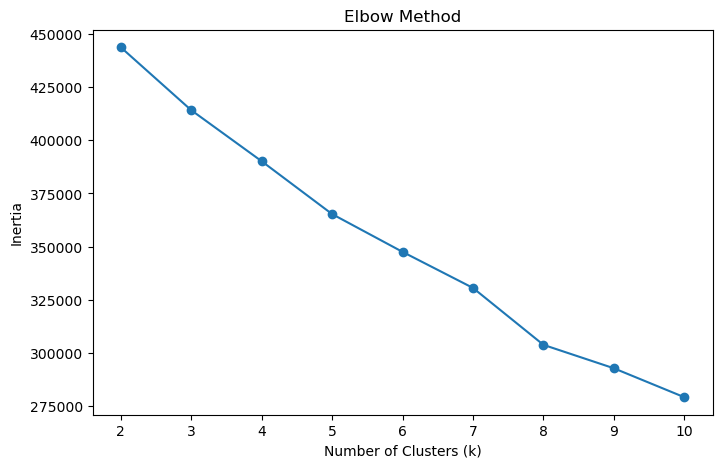

In [5]:
#Elbow method
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Now I will check the silhouette scores for the same range of k values. 

k=2: Silhouette Score=0.0860
k=3: Silhouette Score=0.0893
k=4: Silhouette Score=0.1104
k=5: Silhouette Score=0.1297
k=6: Silhouette Score=0.1452
k=7: Silhouette Score=0.1519
k=8: Silhouette Score=0.1766
k=9: Silhouette Score=0.1736
k=10: Silhouette Score=0.1813


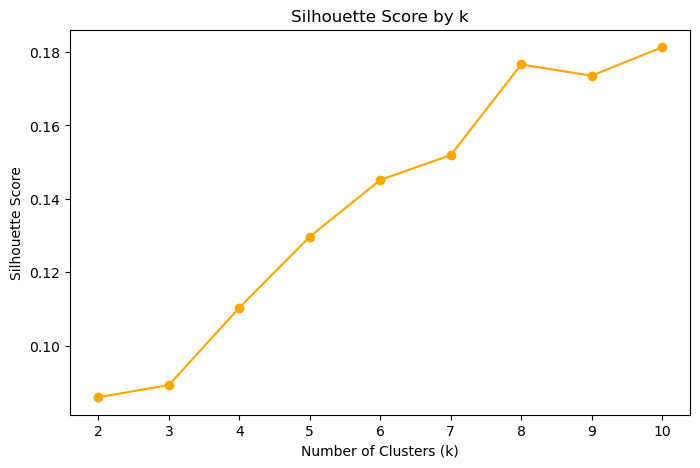

In [6]:
#Silhouette scores
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    sil_scores.append(score)
    print(f"k={k}: Silhouette Score={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.show()

In [7]:
#Best k based on silhouette score
best_k = list(k_range)[np.argmax(sil_scores)]
print(f"Best k: {best_k}")
print(f"Best silhouette score: {max(sil_scores):.4f}")

Best k: 10
Best silhouette score: 0.1813


## Training the Final Model

In [8]:
#Training KMeans with the optimal k
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_model.fit(df_scaled)

#Adding cluster labels to the dataframe
df_clean['cluster'] = final_model.labels_

print(f"Model trained with k={best_k}")
print(f"\nCluster distribution:")
print(df_clean['cluster'].value_counts().sort_index())

Model trained with k=10

Cluster distribution:
cluster
0    1110
1    4991
2    2319
3    5396
4    1695
5     808
6    1922
7    4459
8    4744
9     918
Name: count, dtype: int64


## Visualizing the Clusters

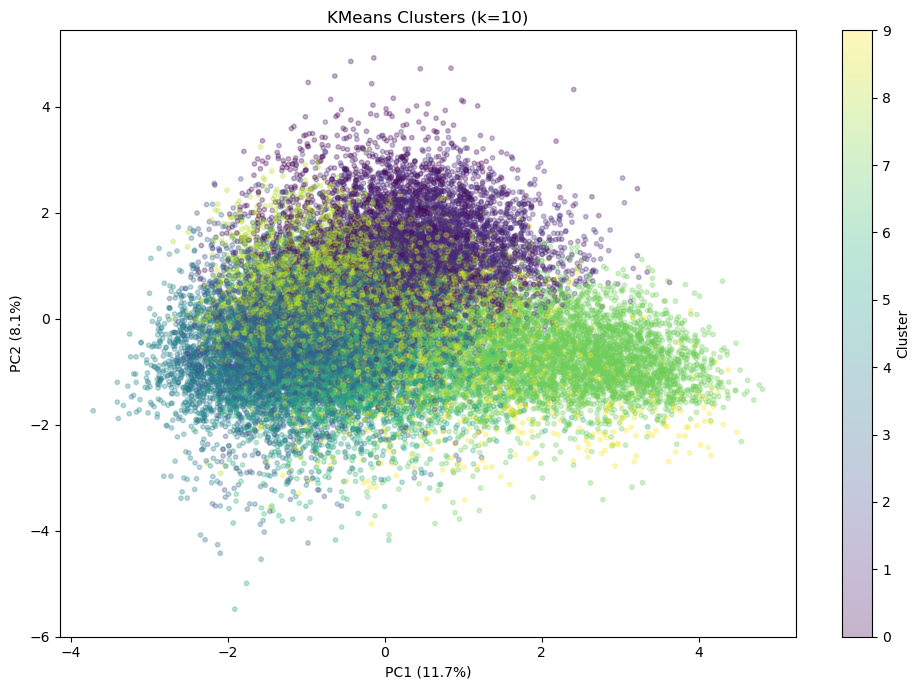

In [9]:
#Using PCA to visualize clusters in 2D
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=final_model.labels_,
                      cmap='viridis', alpha=0.3, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'KMeans Clusters (k={best_k})')
plt.tight_layout()
plt.show()

## Analyzing the Clusters
What does each cluster look like in terms of average feature values?

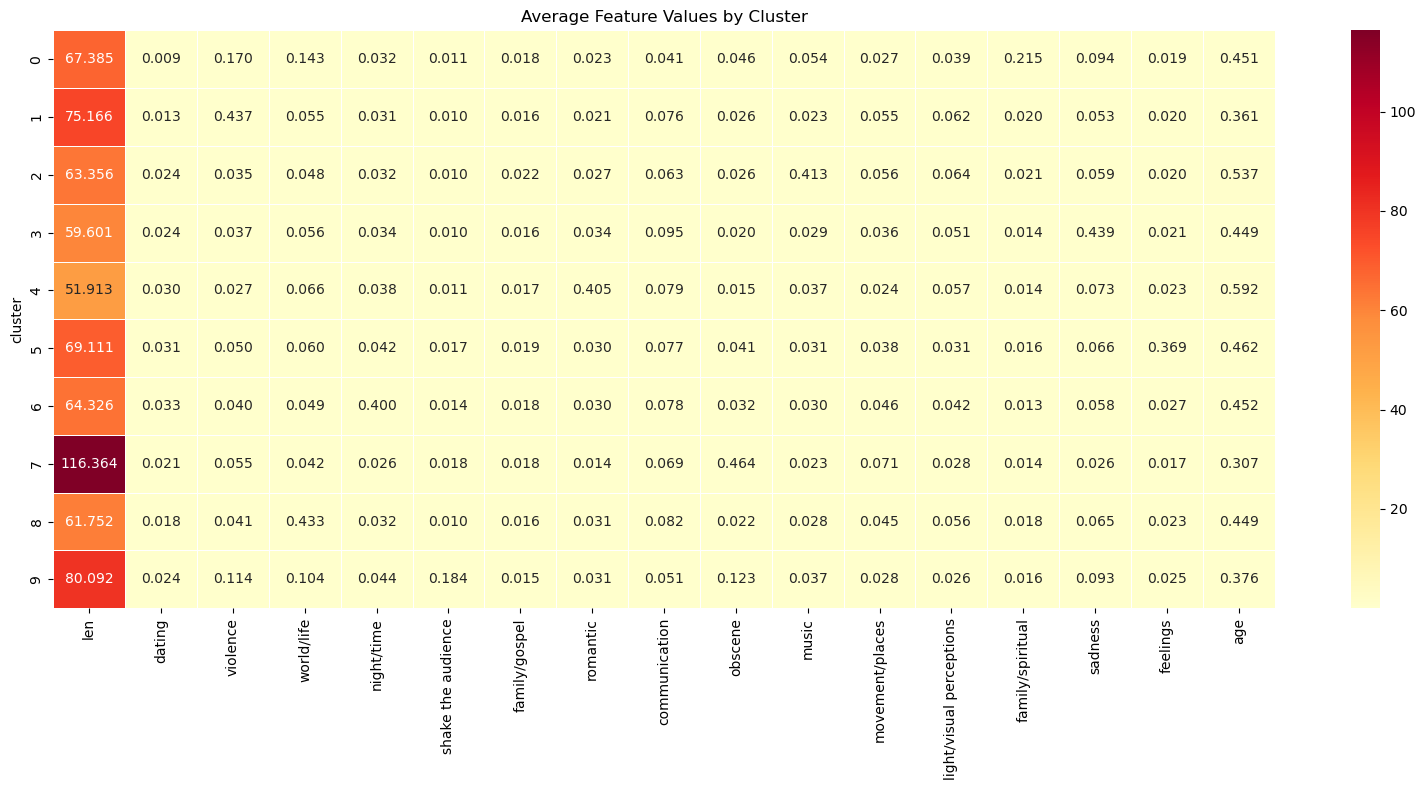

In [10]:
#Average feature values per cluster
cluster_means = df_clean.groupby('cluster').mean()

plt.figure(figsize=(16, 8))
sns.heatmap(cluster_means, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Feature Values by Cluster')
plt.tight_layout()
plt.show()

What genres ended up in each cluster?

In [11]:
#Genre distribution across clusters
df_with_metadata = pd.concat([metadata, df_clean], axis=1)

genre_cluster = pd.crosstab(df_with_metadata['genre'], df_with_metadata['cluster'])
print("Genre distribution across clusters:")
print(genre_cluster)

Genre distribution across clusters:
cluster    0     1    2     3    4    5    6     7     8    9
genre                                                        
blues    174   962  457   795  329  193  376   510   638  169
country  173   611  595  1437  356  140  400   581  1060   91
hip hop   16    90   14    32    3    3   10   673    35   28
jazz     160   600  403   630  334  105  214   618   677  103
pop      205  1097  510  1494  473  193  489  1107  1205  265
reggae   197   478  129   230   55   66  142   626   465  109
rock     185  1153  211   778  145  108  291   344   664  153


What are some example songs from each cluster?

In [12]:
#Sample songs from each cluster
for cluster_id in sorted(df_with_metadata['cluster'].unique()):
    print(f"--- Cluster {cluster_id} ---")
    sample = df_with_metadata[df_with_metadata['cluster'] == cluster_id].sample(5, random_state=42)
    for _, row in sample.iterrows():
        print(f"  {row['artist_name']} - {row['track_name']} ({row['genre']}, {row['topic']})")
    print()

--- Cluster 0 ---
  ziggy marley - changes (reggae, world/life)
  tim hardin - simple song of freedom (country, music)
  the moody blues - the dreamer (pop, world/life)
  nightmares on wax - give thx (jazz, world/life)
  phyllis dillon - close to you (reggae, violence)

--- Cluster 1 ---
  wilco - via chicago (pop, violence)
  bring me the horizon - the house of wolves (rock, violence)
  anthony b - cold feet (reggae, violence)
  josh turner - gravity (country, violence)
  frankie lymon & the teenagers - who put the bomp (in the bomp bomp bomp) (blues, violence)

--- Cluster 2 ---
  junior wells - cha cha cha in blue (blues, music)
  big bill broonzy - slow blues (country, music)
  sam cooke - having a party (pop, music)
  hank williams, jr. - i can't change my tune (country, music)
  janis ian - when the party's over (pop, music)

--- Cluster 3 ---
  shania twain - when he leaves you (country, sadness)
  sugar ray - someday (pop, sadness)
  whitesnake - we wish you well (blues, sadnes

## Applying the Model to the Test Dataset
Now I will apply the trained model to the recommend dataset to predict cluster labels for the user's songs.

In [13]:
#Loading the test data
df_test = pd.read_csv('data/music_rec/recommend - recommend.csv')
print(f"Test data shape: {df_test.shape}")
df_test[['artist_name', 'track_name', 'genre', 'topic']]

Test data shape: (10, 25)


,artist_name,track_name,genre,topic
0,godsmack,immune,rock,world/life
1,dennis brown,second chance,reggae,night/time
2,the black crowes,sister luck,pop,violence
3,jerry lee lewis,your cheating heart,pop,sadness
4,paul anka,eso beso,pop,romantic
5,noro morales,silencio,jazz,violence
6,rage against the machine,pistol grip pump,rock,obscene
7,taste,railway and gun,blues,sadness
8,randy travis,messin' with my mind,country,night/time
9,paramore,playing god,pop,violence


In [14]:
#Cleaning the test data the same way we cleaned training data
test_metadata = df_test[['artist_name', 'track_name', 'genre', 'topic']].copy()

#Dropping same columns plus the extra like/girls column that only exists in test
cols_to_drop_test = ['Unnamed: 0', 'artist_name', 'track_name', 'lyrics', 'topic',
                     'genre', 'release_date', 'like/girls']
df_test_clean = df_test.drop(columns=cols_to_drop_test)

print(f"Test data after cleaning: {df_test_clean.shape}")
print(f"Columns match training: {list(df_test_clean.columns) == list(df_clean.drop(columns=['cluster']).columns)}")

Test data after cleaning: (10, 17)
Columns match training: True


In [15]:
#Scaling the test data with a scaler fit on training data
scaler = StandardScaler()
scaler.fit(pd.read_csv('data/music_rec/train_cleaned.csv'))
df_test_scaled = pd.DataFrame(scaler.transform(df_test_clean), columns=df_test_clean.columns)

print("Test data scaled successfully")

Test data scaled successfully


In [16]:
#Predicting clusters for the test data
test_clusters = final_model.predict(df_test_scaled)

print("User's songs and their cluster assignments:\n")
for i, (_, row) in enumerate(test_metadata.iterrows()):
    print(f"  {row['artist_name']} - {row['track_name']} ({row['genre']}) -> Cluster {test_clusters[i]}")

User's songs and their cluster assignments:

  godsmack - immune (rock) -> Cluster 9
  dennis brown - second chance (reggae) -> Cluster 6
  the black crowes - sister luck (pop) -> Cluster 1
  jerry lee lewis - your cheating heart (pop) -> Cluster 3
  paul anka - eso beso (pop) -> Cluster 4
  noro morales - silencio (jazz) -> Cluster 1
  rage against the machine - pistol grip pump (rock) -> Cluster 7
  taste - railway and gun (blues) -> Cluster 3
  randy travis - messin' with my mind (country) -> Cluster 6
  paramore - playing god (pop) -> Cluster 1


In [17]:
#What clusters does this user listen to most?
print("User's cluster distribution:")
print(pd.Series(test_clusters).value_counts().sort_index())

User's cluster distribution:
1    3
3    2
4    1
6    2
7    1
9    1
Name: count, dtype: int64


## Recommendations
Based on the user's most common cluster I will recommend songs from the training set that belong to the same cluster.

In [18]:
#Finding the user's most common cluster
most_common = pd.Series(test_clusters).value_counts().index[0]
print(f"User's most common cluster: {most_common}")

#Recommending 10 songs from that cluster
recs = df_with_metadata[df_with_metadata['cluster'] == most_common].sample(10, random_state=42)

print(f"\nRecommended Songs for this User (from Cluster {most_common}):\n")
for i, (_, row) in enumerate(recs.iterrows(), 1):
    print(f"  {i}. {row['artist_name']} - {row['track_name']} ({row['genre']}, {row['topic']})")

User's most common cluster: 1

Recommended Songs for this User (from Cluster 1):

  1. wilco - via chicago (pop, violence)
  2. bring me the horizon - the house of wolves (rock, violence)
  3. anthony b - cold feet (reggae, violence)
  4. josh turner - gravity (country, violence)
  5. frankie lymon & the teenagers - who put the bomp (in the bomp bomp bomp) (blues, violence)
  6. the tymes - goodnight my love (blues, violence)
  7. wire - silk skin paws (blues, violence)
  8. milky chance - cocoon (rock, violence)
  9. cody johnson - billy's brother (country, violence)
  10. passafire - growing up (reggae, violence)


## Saving Results

In [19]:
#Saving training data with cluster labels
df_with_metadata.to_csv('data/music_rec/train_clustered.csv', index=False)
print(f"Saved train_clustered.csv: {df_with_metadata.shape}")

#Saving test data with cluster labels
df_test_clean['cluster'] = test_clusters
test_results = pd.concat([test_metadata.reset_index(drop=True),
                          df_test_clean.reset_index(drop=True)], axis=1)
test_results.to_csv('data/music_rec/test_clustered.csv', index=False)
print(f"Saved test_clustered.csv: {test_results.shape}")

Saved train_clustered.csv: (28362, 22)
Saved test_clustered.csv: (10, 22)


## Modeling Summary 

- Tested KMeans with k from 2 to 10 using the elbow method and silhouette scores
- Selected optimal k based on highest silhouette score
- Trained the final model and assigned cluster labels to training data 
- Analyzed clusters through average feature values, genre breakdowns, and sample songs 
- Applied the model to the test dataset and assigned clusters to the user's 10 songs
- Generated recommendation from the user's most common cluster
- Saved all results for the report